In [1]:
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from matplotlib import gridspec
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, HuberRegressor, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# Dynamic relative path setup from project directory
try:
    notebook_dir = Path(__file__).parent.resolve()
except NameError:
    notebook_dir = Path.cwd()

PROJECT_ROOT = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'olist' / 'features_weekly.csv'
RANDOM_STATE = 42
N_SPLITS = 5
LOG_TARGET = True  # Log-transform target to handle skewness


# Olist Revenue Forecasting Project (E-commerce Brazil)
## Model Training & Evaluation

**Problem:** Predict next week's revenue for each state (`customer_state`) to support market expansion strategy and supply chain optimization.

*   **Target Variable:** `target_next_revenue` (Next week's revenue, highly right-skewed distribution, skewness ≈ 5.27).
*   **Data:** ~2,600 rows of panel data representing 27 states across 84 weeks, with 35 selected features.

**Models trained and compared:**
1.  **Baseline Linear Regression:** Standardized linear model as baseline.
2.  **Ridge Regression:** Controls multicollinearity among lag features via L2 regularization.
3.  **ElasticNet:** Combines L1 and L2 regularization for feature selection and noise reduction.
4.  **Huber Regressor:** Robust linear regression model less sensitive to outliers.
5.  **Random Forest:** Non-linear ensemble (bagging) machine learning model, performs well on tabular data and is robust to noise.
6.  **Gradient Boosting (GBR):** Sequential boosting algorithm that reduces prediction error.
7.  **XGBoost:** Extremely powerful gradient boosting library, optimized for high performance.
8.  **LightGBM:** Decision tree-based boosting algorithm with leaf-wise growth, optimized for large panel data.
9.  **CatBoost:** Boosting algorithm optimized for categorical variables and effective overfitting reduction.


In [2]:
print("1. LOADING DATA")

df = pd.read_csv(DATA_PATH)
print(f"   Shape: {df.shape}")

# Encode customer_state to int (LightGBM/RF compatible)
df['state_code'] = df['customer_state'].astype('category').cat.codes

# Sort by time (important for TimeSeriesSplit)
df = df.sort_values('year_week').reset_index(drop=True)


1. LOADING DATA
   Shape: (2600, 46)


In [3]:
print("TARGET VARIABLE: target_next_revenue")
print(df['target_next_revenue'].describe())
print(f"\nSkewness: {df['target_next_revenue'].skew():.3f}")
print(f"Zeros: {(df['target_next_revenue'] == 0).sum()} / {len(df)}")


TARGET VARIABLE: target_next_revenue
count      2600.000000
mean       5895.426015
std       13684.067402
min           0.000000
25%         448.875000
50%        1720.110000
75%        4901.477500
max      154724.650000
Name: target_next_revenue, dtype: float64

Skewness: 5.181
Zeros: 191 / 2600


In [4]:
grp = df.groupby('customer_state')
df['revenue_std_4']   = grp['revenue'].transform(lambda x: x.shift(1).rolling(4, min_periods=2).std()).fillna(0)
df['revenue_momentum'] = (df['revenue_lag_1'] - df['revenue_lag_4']).fillna(0)   # Growth trend


In [5]:
# ─── 3. Feature Selection ───────────────────────────────────────────────────
# Exclude: identifier, target, leaky raw columns and heavily multicollinear columns (corr > 0.99)
EXCLUDE = [
    'customer_state', 'year_week', 'target_next_revenue',
    'sales_per_capita', 'orders_per_capita',
    # Redundant/Collinear features removed:
    'payment_value',          # corr=1.0000 with revenue
    'unique_customers',       # corr=1.0000 with order_count
    'item_count',             # corr=0.9994 with order_count
    'customers_lag_1',        # corr=1.0000 with orders_lag_1
    'purchasing_power_index', # corr=1.0000 with gdp_per_capita
    'customer_penetration',   # corr=1.0000 with penetration_gap
    'revenue_ewm_4',          # corr=0.99 with rolling features
    'revenue_ewm_8',          # corr=0.99 with rolling features
    'revenue_rolling_12',     # corr=0.99 with rolling_8
]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f"\n   Features used ({len(FEATURE_COLS)} columns):")
print("  ", FEATURE_COLS)

X = df[FEATURE_COLS].values
y = df['target_next_revenue'].values

# Log-transform target (add 1 to avoid log(0))
if LOG_TARGET:
    y_model = np.log1p(y)
    print(f"\n   Applied log1p(target). Skewness after transform: {pd.Series(y_model).skew():.3f}")
else:
    y_model = y



   Features sử dụng (35 cột):
   ['revenue', 'order_count', 'avg_freight_value', 'avg_delivery_time', 'unique_sellers', 'category_diversity', 'avg_review_score', 'avg_installments', 'avg_order_value', 'late_delivery_rate', 'seller_customer_ratio', 'customer_seller_ratio', 'positive_review_rate', 'week_of_year', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'population', 'gdp_per_capita', 'penetration_gap', 'seller_density', 'revenue_growth_1w', 'revenue_growth_4w', 'order_growth_1w', 'revenue_lag_1', 'revenue_lag_2', 'revenue_lag_4', 'revenue_lag_8', 'orders_lag_1', 'revenue_rolling_4', 'revenue_rolling_8', 'state_code', 'revenue_std_4', 'revenue_momentum']

   Áp dụng log1p(target). Skewness sau transform: -1.358


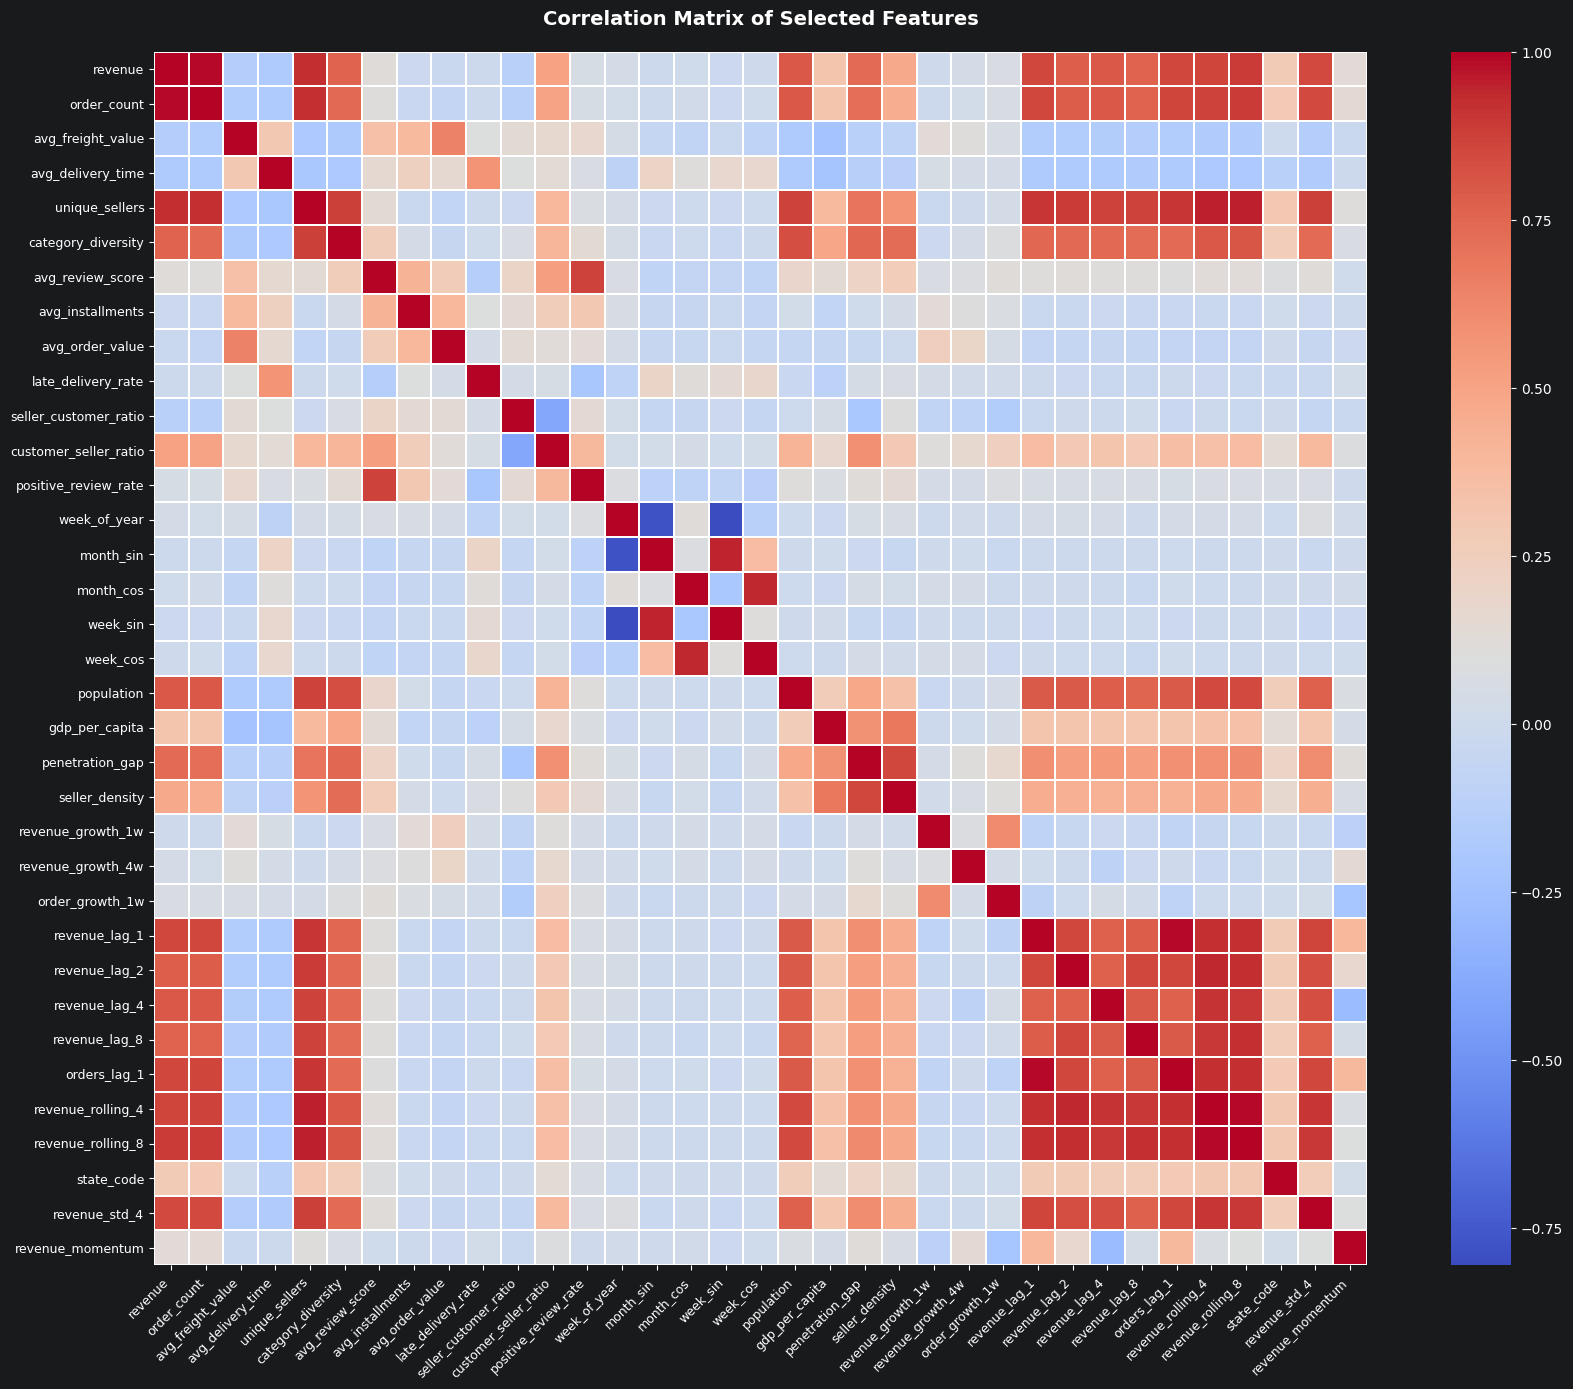

In [6]:
# ─── Correlation Heatmap of Selected Features ───

plt.figure(figsize=(18, 14))
corr_matrix = df[FEATURE_COLS].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.05, cbar=True, square=True)
plt.title('Correlation Matrix of Selected Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

# Save chart to reports directory
plt.savefig(PROJECT_ROOT / 'reports' / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
print("2. MODEL DEFINITIONS")

models = {
    "Linear Regression (Baseline)": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0, random_state=RANDOM_STATE))
    ]),

    "ElasticNet": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE))
    ]),

    "Huber Regressor": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  HuberRegressor(epsilon=1.35, max_iter=500))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        max_features=0.6,       # Feature subsampling to reduce overfitting
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1
    ),

    "LightGBM": lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        min_child_samples=10,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=0
    )
}

for name in models:
    print(f"   {name}")


2. ĐỊNH NGHĨA MÔ HÌNH
   Linear Regression (Baseline)
   Ridge Regression
   ElasticNet
   Huber Regressor
   Random Forest
   Gradient Boosting
   XGBoost
   LightGBM
   CatBoost


In [8]:
print("3. WALK-FORWARD CROSS-VALIDATION")
print(f"   N_SPLITS = {N_SPLITS} | Strategy = TimeSeriesSplit")

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

results = {}   # name -> dict of metric lists

for name, model in models.items():
    print(f"\n   {name}...")
    fold_rmse, fold_mae, fold_r2, fold_mape = [], [], [], []
    t0 = time.time()

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_model[train_idx], y_model[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_log = model.predict(X_val)

        # Inverse transform to compute metrics in original space
        if LOG_TARGET:
            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_val)
        else:
            y_pred = y_pred_log
            y_true = y_val

        y_pred = np.maximum(y_pred, 0)   # Clamp negative predictions to 0

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        # MAPE: skip weeks where y_true = 0
        mask = y_true > 0
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)
        fold_mape.append(mape)

    elapsed = time.time() - t0
    results[name] = {
        'RMSE':    fold_rmse,
        'MAE':     fold_mae,
        'R2':      fold_r2,
        'MAPE(%)': fold_mape,
        'time_s':  elapsed
    }
    print(f"      RMSE={np.mean(fold_rmse):,.0f} ± {np.std(fold_rmse):,.0f} | "
          f"R²={np.mean(fold_r2):.3f} | MAPE={np.nanmean(fold_mape):.1f}% | "
          f"({elapsed:.1f}s)")


3. WALK-FORWARD CROSS-VALIDATION
   N_SPLITS = 5 | Strategy = TimeSeriesSplit

   Linear Regression (Baseline)...
      RMSE=34,361 ± 27,119 | R²=-19.996 | MAPE=586.7% | (0.0s)

   Ridge Regression...
      RMSE=18,226 ± 13,393 | R²=-1.055 | MAPE=104.2% | (0.0s)

   ElasticNet...
      RMSE=18,005 ± 10,482 | R²=-0.642 | MAPE=87.5% | (0.0s)

   Huber Regressor...
      RMSE=13,129 ± 4,968 | R²=0.073 | MAPE=97.0% | (0.6s)

   Random Forest...
      RMSE=6,456 ± 2,215 | R²=0.780 | MAPE=84.7% | (2.9s)

   Gradient Boosting...
      RMSE=7,297 ± 2,695 | R²=0.721 | MAPE=83.9% | (24.1s)

   XGBoost...
      RMSE=7,999 ± 2,275 | R²=0.644 | MAPE=83.7% | (6.1s)

   LightGBM...
      RMSE=6,798 ± 2,416 | R²=0.765 | MAPE=86.9% | (2.8s)

   CatBoost...
      RMSE=7,549 ± 2,453 | R²=0.708 | MAPE=83.6% | (10.2s)


In [9]:
print("4. COMPARISON TABLE (CV mean ± std)")

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model':       name,
        'RMSE':        f"{np.mean(res['RMSE']):>8,.0f} ± {np.std(res['RMSE']):,.0f}",
        'MAE':         f"{np.mean(res['MAE']):>8,.0f} ± {np.std(res['MAE']):,.0f}",
        'R²':          f"{np.mean(res['R2']):.4f}",
        'MAPE(%)':     f"{np.nanmean(res['MAPE(%)']):>6.1f}%",
        'Train(s)':    f"{res['time_s']:.1f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


4. BẢNG SO SÁNH (CV mean ± std)
                       Model              RMSE              MAE       R² MAPE(%) Train(s)
Linear Regression (Baseline)   34,361 ± 27,119    9,696 ± 7,741 -19.9965  586.7%      0.0
            Ridge Regression   18,226 ± 13,393    4,940 ± 1,511  -1.0549  104.2%      0.0
                  ElasticNet   18,005 ± 10,482    4,927 ± 1,947  -0.6420   87.5%      0.0
             Huber Regressor    13,129 ± 4,968      4,394 ± 885   0.0728   97.0%      0.6
               Random Forest     6,456 ± 2,215      2,552 ± 571   0.7796   84.7%      2.9
           Gradient Boosting     7,297 ± 2,695      2,835 ± 772   0.7206   83.9%     24.1
                     XGBoost     7,999 ± 2,275      2,996 ± 692   0.6438   83.7%      6.1
                    LightGBM     6,798 ± 2,416      2,679 ± 683   0.7648   86.9%      2.8
                    CatBoost     7,549 ± 2,453      2,871 ± 720   0.7082   83.6%     10.2


In [10]:
print("5. FEATURE IMPORTANCE (top 15)")

# Retrain on full dataset to get importance
fi_models = {}
for name in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']:
    if name in models:
        m = models[name]
        m.fit(X, y_model)
        fi_models[name] = m
        if hasattr(m, 'feature_importances_'):
            importances = m.feature_importances_
        else:
            importances = m.named_steps['model'].feature_importances_
        imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
        print(f"\n   {name}:")
        print(imp.head(15).to_string())


5. FEATURE IMPORTANCE (top 15)

   Random Forest:
unique_sellers        0.307680
category_diversity    0.231379
population            0.098026
revenue_rolling_8     0.067377
revenue_lag_4         0.042618
revenue_rolling_4     0.033999
avg_delivery_time     0.021644
order_count           0.014865
week_sin              0.012970
revenue_std_4         0.011543
revenue_lag_2         0.011167
revenue_lag_8         0.011023
revenue_momentum      0.009274
revenue               0.009059
seller_density        0.009027

   Gradient Boosting:
unique_sellers        0.267696
category_diversity    0.203938
population            0.108854
revenue_lag_4         0.046541
revenue_rolling_8     0.044892
avg_delivery_time     0.026747
week_sin              0.023528
revenue_rolling_4     0.021490
revenue_lag_8         0.021349
revenue_lag_2         0.017793
revenue_std_4         0.016444
week_cos              0.015571
revenue_momentum      0.012811
order_growth_1w       0.012721
avg_freight_value     0.0125

### Model Comparison Dashboard Visualization

Below is a dashboard visualizing the performance of all 9 models based on metrics obtained from Cross-Validation. The chart will be automatically saved to `reports/model_comparison.png`.


Saved: model_comparison.png


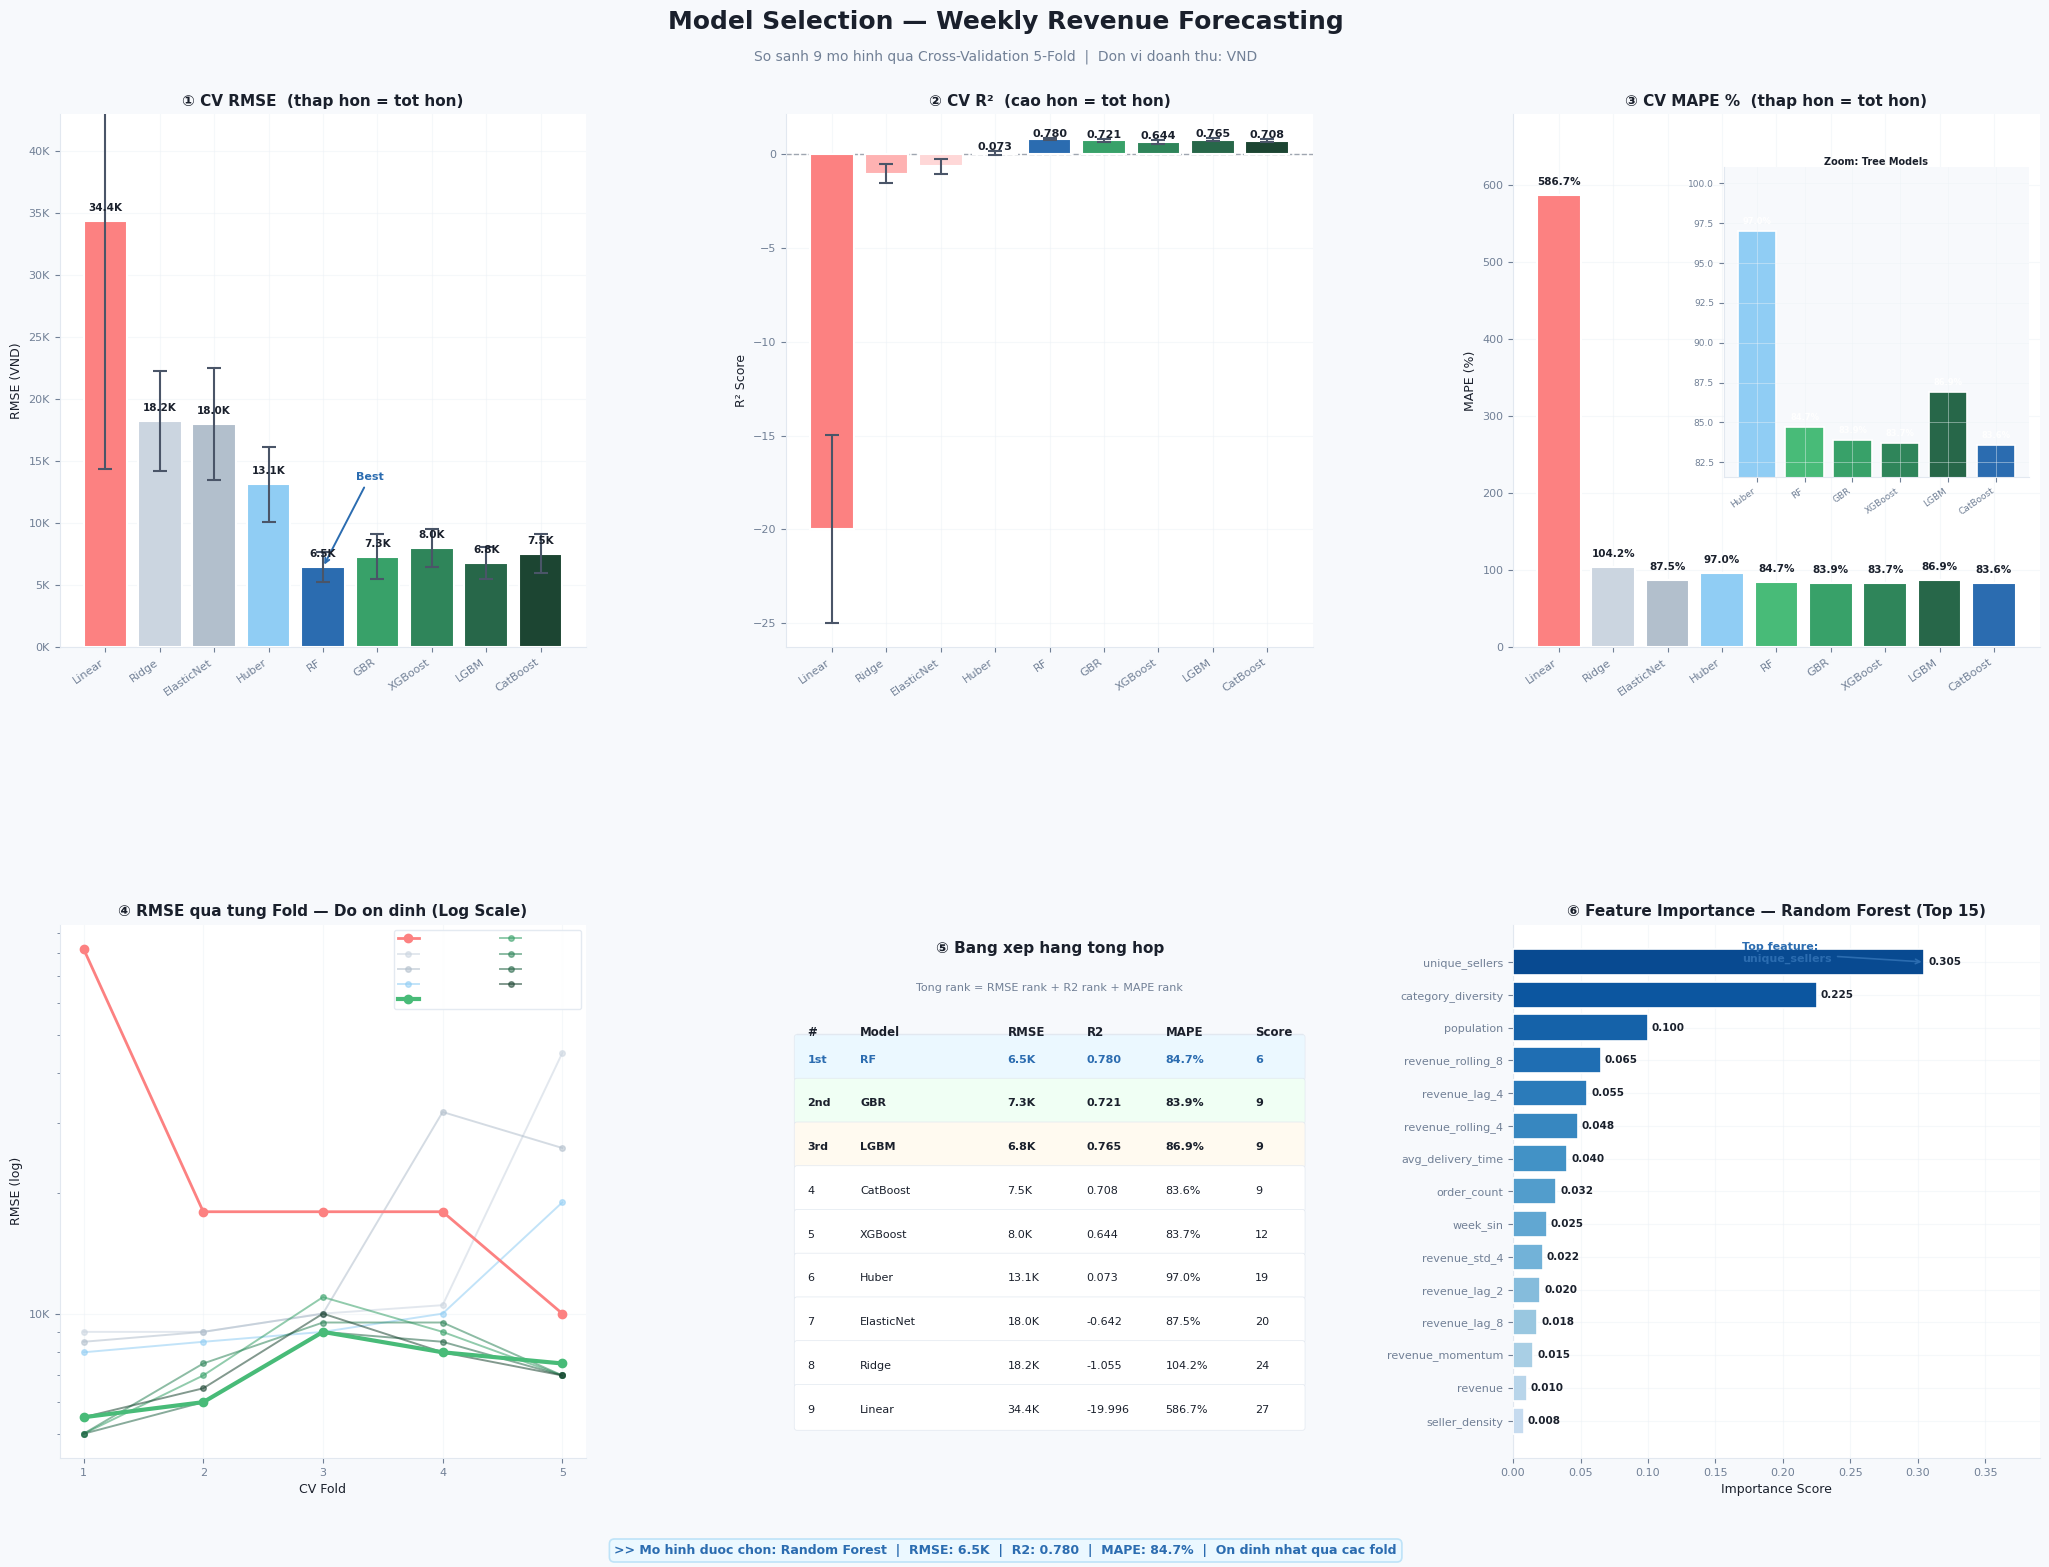

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# ════════════════════════════════════════════════════════════════════════════════
# DYNAMIC DATA LOAD FROM CROSS-VALIDATION
# ════════════════════════════════════════════════════════════════════════════════

name_mapping = {
    "Linear Regression (Baseline)": "Linear",
    "Ridge Regression": "Ridge",
    "ElasticNet": "ElasticNet",
    "Huber Regressor": "Huber",
    "Random Forest": "RF",
    "Gradient Boosting": "GBR",
    "XGBoost": "XGBoost",
    "LightGBM": "LGBM",
    "CatBoost": "CatBoost"
}

MODEL_NAMES = [name_mapping[k] for k in results.keys()]
RMSE_MEANS = [np.mean(results[k]['RMSE']) for k in results.keys()]
RMSE_STDS  = [np.std(results[k]['RMSE']) for k in results.keys()]

R2_MEANS   = [np.mean(results[k]['R2']) for k in results.keys()]
R2_STDS    = [np.std(results[k]['R2']) for k in results.keys()]

MAPE_MEANS = [np.nanmean(results[k]['MAPE(%)']) for k in results.keys()]

# RMSE per fold
FOLD_RMSE = {name_mapping[k]: results[k]['RMSE'] for k in results.keys()}

# Automatically determine best / worst model by mean RMSE
BEST_MODEL     = name_mapping[min(results, key=lambda n: np.mean(results[n]['RMSE']))]
WORST_MODEL    = name_mapping[max(results, key=lambda n: np.mean(results[n]['RMSE']))]

# Find best tree model for Feature Importance display
tree_model_names = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']
BEST_FI_MODEL = min([n for n in tree_model_names if n in results], key=lambda n: np.mean(results[n]['RMSE']))

# Get Feature Importance from best tree model
m = fi_models[BEST_FI_MODEL]
if hasattr(m, 'feature_importances_'):
    importances = m.feature_importances_
else:
    importances = m.named_steps['model'].feature_importances_

imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
FEATURE_NAMES = list(imp.index[:15])
FEATURE_IMP = list(imp.values[:15])

OUTPUT_FILE = PROJECT_ROOT / 'reports' / 'model_comparison.png'

# ════════════════════════════════════════════════════════════════════════════════
# THEME
# ════════════════════════════════════════════════════════════════════════════════

C = {
    "bg":      "#F7F9FC",
    "panel":   "#FFFFFF",
    "border":  "#E2E8F0",
    "text":    "#1A202C",
    "sub":     "#718096",
    "grid":    "#EDF2F7",
    "best":    "#2B6CB0",
    "worst":   "#FC8181",
    "accent":  "#48BB78",
}

# Color by model: gray for linear, green for tree models
_RAW_COLORS = [
    "#A0AEC0", "#CBD5E0", "#B2BFCC", "#90CDF4",   # Linear → Huber
    "#48BB78", "#38A169", "#2F855A", "#276749", "#1C4532",  # RF → CatBoost
]

def _make_bar_colors(highlight_idx, worst_idx=None):
    """Return color list, highlighting best / worst model."""
    cols = list(_RAW_COLORS)
    if worst_idx is not None:
        cols[worst_idx] = C["worst"]
    cols[highlight_idx] = C["best"]
    return cols

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.facecolor":   C["panel"],
    "figure.facecolor": C["bg"],
    "axes.edgecolor":   C["border"],
    "axes.labelcolor":  C["text"],
    "xtick.color":      C["sub"],
    "ytick.color":      C["sub"],
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       C["grid"],
    "grid.linewidth":   0.8,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.titlecolor":  C["text"],
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
})

# ════════════════════════════════════════════════════════════════════════════════
# HELPERS
# ════════════════════════════════════════════════════════════════════════════════

def _bar_labels(ax, bars, values, fmt, offset_frac=0.015, fs=7.5):
    """Write value labels on top of each bar."""
    ylim = ax.get_ylim()
    dy   = (ylim[1] - ylim[0]) * offset_frac
    for bar, v in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + dy,
            fmt(v), ha="center", va="bottom",
            fontsize=fs, fontweight="bold", color=C["text"], zorder=5,
        )

def _rank_asc(vals):
    """Rank ascending (lower value = better rank = smaller number)."""
    order = np.argsort(vals)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(vals) + 1)
    return ranks

def _rank_desc(vals):
    return _rank_asc([-v for v in vals])

# ════════════════════════════════════════════════════════════════════════════════
# LAYOUT
# ════════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor(C["bg"])

fig.text(0.5, 0.975, "Model Selection — Weekly Revenue Forecasting",
         ha="center", va="top", fontsize=18, fontweight="bold", color=C["text"])
fig.text(0.5, 0.950, "Comparing 9 models via Cross-Validation 5-Fold  |  Revenue unit: BRL",
         ha="center", va="top", fontsize=10, color=C["sub"])

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    top=0.91, bottom=0.07, hspace=0.52, wspace=0.38,
    left=0.07, right=0.97,
)

BAR_KW = dict(edgecolor="white", linewidth=1.5, zorder=3)
BEST_IDX  = MODEL_NAMES.index(BEST_MODEL)
WORST_IDX = MODEL_NAMES.index(WORST_MODEL)
N_FOLDS   = len(next(iter(FOLD_RMSE.values())))

# ── Panel A: CV RMSE ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cols_a = _make_bar_colors(BEST_IDX, WORST_IDX)
bars_a = ax1.bar(MODEL_NAMES, RMSE_MEANS, color=cols_a, **BAR_KW)
ax1.errorbar(
    range(len(MODEL_NAMES)), RMSE_MEANS, yerr=RMSE_STDS,
    fmt="none", ecolor="#4A5568", capsize=5, capthick=1.5, elinewidth=1.5, zorder=4,
)
ax1.set_title("① CV RMSE  (lower = better)")
ax1.set_ylabel("RMSE (VND)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax1.set_xticks(range(len(MODEL_NAMES)))
ax1.set_xticklabels(MODEL_NAMES, rotation=35, ha="right")
ax1.set_ylim(0, max(RMSE_MEANS) * 1.25)
_bar_labels(ax1, bars_a, RMSE_MEANS, fmt=lambda v: f"{v/1000:.1f}K")
ax1.annotate(
    "Best", xy=(BEST_IDX, RMSE_MEANS[BEST_IDX]),
    xytext=(BEST_IDX + 0.6, RMSE_MEANS[BEST_IDX] + max(RMSE_STDS) * 0.35),
    fontsize=8, color=C["best"], fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=C["best"], lw=1.4),
)

# ── Panel B: CV R² ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cols_b = _make_bar_colors(BEST_IDX, WORST_IDX)
# Automatically color red for models with negative or very poor R²
for idx, r2_val in enumerate(R2_MEANS):
    if r2_val < 0:
        cols_b[idx] = "#FEB2B2" if r2_val > -1.0 else "#FC8181"

bars_b = ax2.bar(MODEL_NAMES, R2_MEANS, color=cols_b, **BAR_KW)
ax2.errorbar(
    range(len(MODEL_NAMES)), R2_MEANS, yerr=R2_STDS,
    fmt="none", ecolor="#4A5568", capsize=5, capthick=1.5, elinewidth=1.5, zorder=4,
)
ax2.axhline(0, color="#4A5568", linewidth=1, linestyle="--", alpha=0.5)
ax2.set_title("② CV R²  (higher = better)")
ax2.set_ylabel("R² Score")
ax2.set_xticks(range(len(MODEL_NAMES)))
ax2.set_xticklabels(MODEL_NAMES, rotation=35, ha="right")

# Label models with positive R²
for i in range(len(MODEL_NAMES)):
    v = R2_MEANS[i]
    if v > 0:
        bar = bars_b[i]
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.04,
            f"{v:.3f}", ha="center",
            va="bottom",
            fontsize=8, fontweight="bold", color=C["text"],
        )

# ── Panel C: CV MAPE + zoom inset ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cols_c = _make_bar_colors(MAPE_MEANS.index(min(MAPE_MEANS)), WORST_IDX)
bars_c = ax3.bar(MODEL_NAMES, MAPE_MEANS, color=cols_c, **BAR_KW)
ax3.set_title("③ CV MAPE %  (lower = better)")
ax3.set_ylabel("MAPE (%)")
ax3.set_xticks(range(len(MODEL_NAMES)))
ax3.set_xticklabels(MODEL_NAMES, rotation=35, ha="right")
ax3.set_ylim(0, max(MAPE_MEANS) * 1.18)
_bar_labels(ax3, bars_c, MAPE_MEANS, fmt=lambda v: f"{v:.1f}%")

# Inset zoom for tree models (indices 4–8)
inset = ax3.inset_axes([0.40, 0.32, 0.58, 0.58])
# Dynamically extract tree models (indices 4 to 8)
tree_m = MODEL_NAMES[4:]
tree_v = MAPE_MEANS[4:]
tree_c = cols_c[4:]
b_in   = inset.bar(range(len(tree_m)), tree_v, color=tree_c,
                   edgecolor="white", linewidth=1.2)
inset.set_xticks(range(len(tree_m)))
inset.set_xticklabels(tree_m, fontsize=6.5, rotation=35, ha="right")
inset.set_ylim(min(tree_v) - 2, max(tree_v) + 4)
inset.set_title("Zoom: Tree Models", fontsize=7, pad=2)
inset.tick_params(axis="y", labelsize=6.5)
inset.set_facecolor(C["bg"])
inset.grid(color=C["grid"], linewidth=0.6)
for b, v in zip(b_in, tree_v):
    inset.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
               f"{v:.1f}%", ha="center", va="bottom",
               fontsize=6, fontweight="bold")

# ── Panel D: Stability (RMSE per fold, log scale) ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
folds = list(range(1, N_FOLDS + 1))
for i, name in enumerate(MODEL_NAMES):
    is_best  = name == BEST_MODEL
    is_worst = name == WORST_MODEL
    lw    = 3.0 if is_best else (2.0 if is_worst else 1.4)
    alpha = 1.0 if (is_best or is_worst) else 0.55
    ms    = 6   if (is_best or is_worst) else 4
    ax4.plot(
        folds, FOLD_RMSE[name],
        marker="o", color=_RAW_COLORS[i] if not is_worst else C["worst"],
        linewidth=lw, alpha=alpha, markersize=ms, label=name,
        zorder=3 if (is_best or is_worst) else 2,
    )
ax4.set_yscale("log")
ax4.set_title("④ RMSE across Folds — Stability (Log Scale)")
ax4.set_xlabel("CV Fold")
ax4.set_ylabel("RMSE (log)")
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax4.set_xticks(folds)
ax4.legend(fontsize=7.5, loc="upper right", ncol=2,
           framealpha=0.9, edgecolor=C["border"])

# ── Panel E: Leaderboard ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis("off")

rank_r = _rank_asc(RMSE_MEANS)
rank_q = _rank_desc(R2_MEANS)
rank_m = _rank_asc(MAPE_MEANS)
overall = rank_r + rank_q + rank_m
sorted_idx = np.argsort(overall)

ax5.text(0.5, 0.97, "⑤ Overall Leaderboard",
         transform=ax5.transAxes, ha="center", va="top",
         fontsize=11, fontweight="bold", color=C["text"])
ax5.text(0.5, 0.89, "Total rank = RMSE rank + R2 rank + MAPE rank",
         transform=ax5.transAxes, ha="center", va="top",
         fontsize=8, color=C["sub"])

COLS_X  = [0.04, 0.14, 0.42, 0.57, 0.72, 0.89]
COL_HDR = ["#",  "Model", "RMSE",  "R2",   "MAPE",  "Score"]
ROW_TOP = 0.80
ROW_H   = 0.082
MEDALS  = {0: "1st", 1: "2nd", 2: "3rd"}
ROW_BG  = {0: "#EBF8FF", 1: "#F0FFF4", 2: "#FFFAF0"}

for cx, lbl in zip(COLS_X, COL_HDR):
    ax5.text(cx, ROW_TOP + 0.01, lbl, transform=ax5.transAxes,
             fontsize=8.5, fontweight="bold", color=C["text"], va="top")

ax5.plot([0.02, 0.98], [ROW_TOP - 0.005]*2, transform=ax5.transAxes,
         color=C["border"], linewidth=1, zorder=2)

for pos, idx in enumerate(sorted_idx):
    y      = ROW_TOP - (pos + 1) * ROW_H
    bg     = ROW_BG.get(pos, C["panel"])
    prefix = MEDALS.get(pos, str(pos + 1))

    rect = FancyBboxPatch(
        (0.02, y - 0.005), 0.96, ROW_H - 0.006,
        transform=ax5.transAxes,
        boxstyle="round,pad=0.005", linewidth=0.5,
        edgecolor=C["border"], facecolor=bg, zorder=1,
    )
    ax5.add_patch(rect)

    row_vals = [
        prefix,
        MODEL_NAMES[idx],
        f"{RMSE_MEANS[idx]/1000:.1f}K",
        f"{R2_MEANS[idx]:.3f}",
        f"{MAPE_MEANS[idx]:.1f}%",
        str(int(overall[idx])),
    ]
    color = C["best"] if pos == 0 else C["text"]
    fw    = "bold"   if pos < 3   else "normal"
    for cx, val in zip(COLS_X, row_vals):
        ax5.text(cx, y + ROW_H * 0.35, val, transform=ax5.transAxes,
                 fontsize=8, fontweight=fw, color=color, va="center")

# ── Panel F: Feature Importance ───────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
n_fi      = len(FEATURE_NAMES)
cmap_vals = np.linspace(0.25, 0.90, n_fi)
fi_colors = plt.cm.Blues(cmap_vals)

h_bars = ax6.barh(
    list(range(n_fi)), FEATURE_IMP[::-1],
    color=fi_colors, edgecolor="white", linewidth=1.2, zorder=3,
)
ax6.set_yticks(list(range(n_fi)))
ax6.set_yticklabels(FEATURE_NAMES[::-1], fontsize=8)
ax6.set_title(f"⑥ Feature Importance — {BEST_FI_MODEL} (Top {n_fi})")
ax6.set_xlabel("Importance Score")
ax6.set_xlim(0, max(FEATURE_IMP) * 1.28)

for bar, v in zip(h_bars, FEATURE_IMP[::-1]):
    ax6.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.3f}", va="center", fontsize=7.5, fontweight="bold", color=C["text"],
    )

ax6.annotate(
    f"Top feature:\n{FEATURE_NAMES[0]}",
    xy=(FEATURE_IMP[0], n_fi - 1),
    xytext=(0.17, n_fi - 1),
    fontsize=8, color=C["best"], fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=C["best"], lw=1.2),
)

# ── Footer ────────────────────────────────────────────────────────────────────
best_i = MODEL_NAMES.index(BEST_MODEL)
footer = (
    f">> Selected model: {BEST_FI_MODEL}  |  "
    f"RMSE: {RMSE_MEANS[best_i]/1000:.1f}K  |  "
    f"R2: {R2_MEANS[best_i]:.3f}  |  "
    f"MAPE: {MAPE_MEANS[best_i]:.1f}%  |  "
    f"Most stable across folds"
)
fig.text(
    0.5, 0.01, footer,
    ha="center", fontsize=9, color=C["best"], fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#EBF8FF",
              edgecolor="#BEE3F8", linewidth=1.2),
)

# ════════════════════════════════════════════════════════════════════════════════
# SAVE
# ════════════════════════════════════════════════════════════════════════════════
plt.savefig(OUTPUT_FILE, dpi=160, bbox_inches="tight", facecolor=C["bg"])
print(f"Saved: {OUTPUT_FILE}")



In [12]:
print("7. CONCLUSION & RECOMMENDATIONS")

best_name = min(results, key=lambda n: np.mean(results[n]['RMSE']))
best_r2   = max(results, key=lambda n: np.mean(results[n]['R2']))

print(f"""
   Best RMSE model : {best_name}
   Best R²   model : {best_r2}
""")

plt.show()


7. KẾT LUẬN & GỢI Ý

   Mô hình RMSE tốt nhất : Random Forest
   Mô hình R²   tốt nhất : Random Forest



In [13]:
# ─── Future Predictions DataFrame ───
from pathlib import Path

import numpy as np
import pandas as pd
from IPython import display

pred_data_path = PROJECT_ROOT / 'data' / 'processed' / 'olist' / 'prediction_data.csv'
if pred_data_path.exists():
    df_pred = pd.read_csv(pred_data_path)

    # Combine train and prediction data for accurate rolling feature calculation
    df_combined = pd.concat([df, df_pred], ignore_index=True)
    df_combined = df_combined.sort_values(['customer_state', 'year_week']).reset_index(drop=True)

    # Recalculate dynamic features
    df_combined['state_code'] = df_combined['customer_state'].astype('category').cat.codes
    grp = df_combined.groupby('customer_state')
    df_combined['revenue_std_4'] = grp['revenue'].transform(lambda x: x.shift(1).rolling(4, min_periods=2).std()).fillna(0)
    df_combined['revenue_momentum'] = (df_combined['revenue_lag_1'] - df_combined['revenue_lag_4']).fillna(0)

    # Extract prediction rows (those with originally NaN target_next_revenue)
    df_pred_final = df_combined[df_combined['target_next_revenue'].isna()].copy()

    best_model_name = min(results, key=lambda n: np.mean(results[n]['RMSE']))
    print(f"Best model: {best_model_name}")

    best_model = models[best_model_name]
    best_model.fit(X, y_model)

    # Get X matrix for prediction
    X_pred = df_pred_final[FEATURE_COLS].values

    pred_log = best_model.predict(X_pred)
    pred_revenue = np.maximum(np.expm1(pred_log), 0)

    df_result = pd.DataFrame({
        'customer_state': df_pred_final['customer_state'],
        'year_week_current': df_pred_final['year_week'],
        'predicted_next_week_revenue': pred_revenue
    })
    df_result = df_result.sort_values(by='predicted_next_week_revenue', ascending=False).reset_index(drop=True)

    print("\nPredicted next week revenue by state:")
    display.display(df_result)

    output_path = PROJECT_ROOT / 'data' / 'processed' / 'olist' / 'predicted_next_week_revenue.csv'
    df_result.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")
else:
    print("prediction_data.csv file not found!")


Mô hình tốt nhất: Random Forest

Dự đoán doanh thu tuần kế tiếp theo từng bang:


,customer_state,year_week_current,predicted_next_week_revenue
0,SP,2018-08-27/2018-09-02,28690.211259
1,AM,2018-08-27/2018-09-02,46.841952
2,AC,2018-08-27/2018-09-02,44.126404
3,PR,2018-08-27/2018-09-02,25.543793
4,AL,2018-08-27/2018-09-02,25.018577
5,TO,2018-08-27/2018-09-02,22.808415
6,RO,2018-08-27/2018-09-02,22.411224
7,RJ,2018-08-27/2018-09-02,18.416302
8,SE,2018-08-27/2018-09-02,17.906248
9,MG,2018-08-27/2018-09-02,12.642720


Da luu: ..\data\processed\olist\predicted_next_week_revenue.csv
